# Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import base64
from io import BytesIO

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from itertools import combinations

import seaborn as sns
import matplotlib.pyplot as plt

import scikit_posthocs as sp

# Download Dados IBOVESPA

In [2]:
# Download dos dados da API do Yahoo Finance
ticker = "^BVSP"
df_ibovespa = yf.download(ticker, start="2010-01-01")

# Filtrar apenas as colunas de fechamento e o volume
df_ibovespa = df_ibovespa[['Close', 'Volume']].dropna()

# Corrigir MultiIndex
if isinstance(df_ibovespa.columns, pd.MultiIndex):
    df_ibovespa.columns = df_ibovespa.columns.get_level_values(0)

# Filtrar apenas volumes maiores que zeros
df_ibovespa = df_ibovespa[df_ibovespa['Volume'] > 0]

[*********************100%***********************]  1 of 1 completed


In [3]:
df_ibovespa

Price,Close,Volume
Date,,
2010-01-04,70045.0,1655400
2010-01-05,70240.0,1984200
2010-01-06,70729.0,2243600
2010-01-07,70451.0,1555000
2010-01-08,70263.0,1634400
...,...,...
2026-03-17,180410.0,9332600
2026-03-18,179640.0,9750200
2026-03-19,180271.0,12560400


# Engenharia de Features

In [4]:
# Retorno simples
df_ibovespa['retorno'] = df_ibovespa['Close'].pct_change()

# Volume ajustado (remoção de tendência do crescimento do volume com o tempo)
df_ibovespa['vol_mm252'] = df_ibovespa['Volume'].rolling(252).mean()
df_ibovespa['vol_rel'] = df_ibovespa['Volume'] / df_ibovespa['vol_mm252']

# Dia da semana
df_ibovespa['weekday'] = df_ibovespa.index.day_name()

# Remover NaNs
df_ibovespa = df_ibovespa.dropna()

# Ordem dos dias
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

In [5]:
df_ibovespa

Price,Close,Volume,retorno,vol_mm252,vol_rel,weekday
Date,,,,,,
2011-01-24,69427.0,1474400,0.004253,1.890256e+06,0.780000,Monday
2011-01-26,68709.0,2542400,-0.010342,1.893776e+06,1.342503,Wednesday
2011-01-27,68051.0,2304400,-0.009577,1.895047e+06,1.216012,Thursday
2011-01-28,66698.0,2544000,-0.019882,1.896239e+06,1.341603,Friday
2011-01-31,66575.0,2253800,-0.001844,1.899012e+06,1.186828,Monday
...,...,...,...,...,...,...
2026-03-17,180410.0,9332600,0.002974,9.108850e+06,1.024564,Tuesday
2026-03-18,179640.0,9750200,-0.004268,9.089713e+06,1.072663,Wednesday
2026-03-19,180271.0,12560400,0.003513,9.095655e+06,1.380923,Thursday


# Análise Exploratória de Dados (EDA)

In [6]:
def analise_eda(df, col):
    print(f"\n===== EDA: {col} =====")

    print("\nMédia por dia:")
    print(df.groupby('weekday')[col].mean())

    print("\nDesvio padrão:")
    print(df.groupby('weekday')[col].std())

    print("\nAssimetria:", stats.skew(df[col]))
    print("Curtose:", stats.kurtosis(df[col]))

    # Boxplot
    sns.boxplot(data=df, x='weekday', y=col, order=order)
    plt.title(f'Boxplot - {col}')
    plt.show()

    # Histograma
    sns.histplot(df[col], kde=True)
    plt.title(f'Histograma - {col}')
    plt.show()


===== EDA: retorno =====

Média por dia:
weekday
Friday      -0.000195
Monday      -0.000265
Thursday     0.000281
Tuesday      0.001404
Wednesday    0.000614
Name: retorno, dtype: float64

Desvio padrão:
weekday
Friday       0.014576
Monday       0.015752
Thursday     0.015108
Tuesday      0.014054
Wednesday    0.014050
Name: retorno, dtype: float64

Assimetria: -0.5020707605282068
Curtose: 10.703163796062448


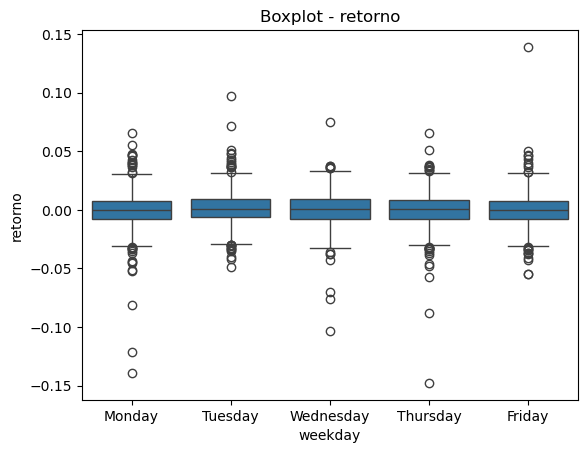

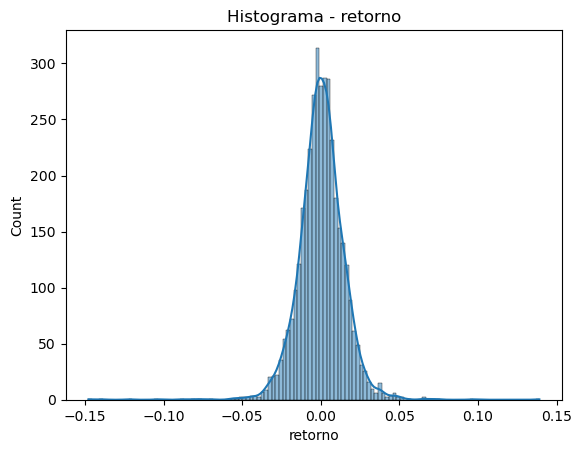

In [7]:
analise_eda(df_ibovespa, 'retorno')


===== EDA: vol_rel =====

Média por dia:
weekday
Friday       1.101653
Monday       0.943504
Thursday     1.094616
Tuesday      1.051267
Wednesday    1.109013
Name: vol_rel, dtype: float64

Desvio padrão:
weekday
Friday       0.360603
Monday       0.321778
Thursday     0.326315
Tuesday      0.294323
Wednesday    0.316685
Name: vol_rel, dtype: float64

Assimetria: 1.4674096038235074
Curtose: 5.046145966064129


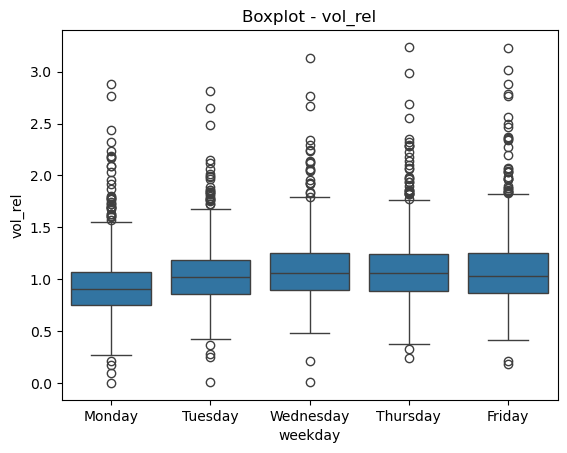

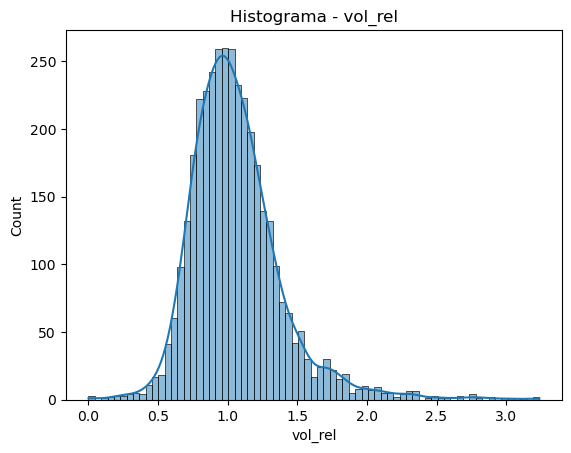

In [8]:
analise_eda(df_ibovespa, 'vol_rel')

# Testes Paramétricos

In [9]:
def anova_test(df, col):
    model = ols(f'{col} ~ C(weekday)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    return anova_table

def levene_test(df, col):
    groups = [df[df['weekday'] == d][col] for d in order]
    stat, p = stats.levene(*groups)
    return stat, p

def welch_anova(df, col):
    return pg.welch_anova(dv=col, between='weekday', data=df)['p_unc'].values[0]

def tukey_test(df, col):
    tukey = pairwise_tukeyhsd(df[col], df['weekday'])
    return pd.DataFrame(data=tukey._results_table.data[1:], 
                        columns=tukey._results_table.data[0])

In [10]:
# Retorno
print("\n===== ANOVA (Retorno) =====")
print(anova_test(df_ibovespa, 'retorno'))

print("\n===== LEVENE (Retorno) =====")
print(levene_test(df_ibovespa, 'retorno'))

print("\n===== WELCH (Retorno) =====")
print(welch_anova(df_ibovespa, 'retorno'))

print("\n===== TUKEY (Retorno) =====")
print(tukey_test(df_ibovespa, 'retorno'))


===== ANOVA (Retorno) =====
              sum_sq      df         F    PR(>F)
C(weekday)  0.001382     4.0  1.594011  0.173017
Residual    0.805720  3718.0       NaN       NaN

===== LEVENE (Retorno) =====
(np.float64(0.16119623763916213), np.float64(0.9579456654922722))

===== WELCH (Retorno) =====
0.16118218693287886

===== TUKEY (Retorno) =====
     group1     group2  meandiff   p-adj   lower   upper  reject
0    Friday     Monday   -0.0001  1.0000 -0.0022  0.0020   False
1    Friday   Thursday    0.0005  0.9716 -0.0016  0.0026   False
2    Friday    Tuesday    0.0016  0.2237 -0.0005  0.0037   False
3    Friday  Wednesday    0.0008  0.8267 -0.0013  0.0029   False
4    Monday   Thursday    0.0005  0.9533 -0.0015  0.0026   False
5    Monday    Tuesday    0.0017  0.1850 -0.0004  0.0038   False
6    Monday  Wednesday    0.0009  0.7776 -0.0012  0.0030   False
7  Thursday    Tuesday    0.0011  0.5813 -0.0010  0.0032   False
8  Thursday  Wednesday    0.0003  0.9924 -0.0017  0.0024   False


In [11]:
# Volume
print("\n===== ANOVA (Volume) =====")
print(anova_test(df_ibovespa, 'vol_rel'))

print("\n===== LEVENE (Volume) =====")
print(levene_test(df_ibovespa, 'vol_rel'))

print("\n===== WELCH (Volume) =====")
print(welch_anova(df_ibovespa, 'vol_rel'))

print("\n===== TUKEY (Volume) =====")
print(tukey_test(df_ibovespa, 'vol_rel'))


===== ANOVA (Volume) =====
                sum_sq      df          F        PR(>F)
C(weekday)   14.134455     4.0  33.539528  1.581488e-27
Residual    391.716188  3718.0        NaN           NaN

===== LEVENE (Volume) =====
(np.float64(2.0773847097777236), np.float64(0.08110504843023789))

===== WELCH (Volume) =====
4.745617392337462e-27

===== TUKEY (Volume) =====
     group1     group2  meandiff   p-adj   lower   upper  reject
0    Friday     Monday   -0.1581  0.0000 -0.2041 -0.1122    True
1    Friday   Thursday   -0.0070  0.9937 -0.0530  0.0390   False
2    Friday    Tuesday   -0.0504  0.0235 -0.0964 -0.0044    True
3    Friday  Wednesday    0.0074  0.9924 -0.0385  0.0532   False
4    Monday   Thursday    0.1511  0.0000  0.1052  0.1971    True
5    Monday    Tuesday    0.1078  0.0000  0.0618  0.1537    True
6    Monday  Wednesday    0.1655  0.0000  0.1197  0.2113    True
7  Thursday    Tuesday   -0.0433  0.0752 -0.0893  0.0026   False
8  Thursday  Wednesday    0.0144  0.9123 -0.03

# Teste Não-Paramétricos (Robustos)

In [12]:
def kruskal_test(df, col):
    groups = [df[df['weekday'] == d][col] for d in order]
    stat, p = stats.kruskal(*groups)
    return stat, p

def dunn_test(df, col):
    dunn = sp.posthoc_dunn(
        df,
        val_col=col,
        group_col='weekday',
        p_adjust='holm'
    )
    return dunn

In [13]:
# Retorno
print("\n===== KRUSKAL (Retorno) =====")
print(kruskal_test(df_ibovespa, 'retorno'))

print("\n===== DUNN (Retorno) =====")
print(dunn_test(df_ibovespa, 'retorno'))


===== KRUSKAL (Retorno) =====
(np.float64(5.234205994476724), np.float64(0.2640994429819428))

===== DUNN (Retorno) =====
             Friday  Monday  Thursday   Tuesday  Wednesday
Friday     1.000000     1.0       1.0  0.337577        1.0
Monday     1.000000     1.0       1.0  1.000000        1.0
Thursday   1.000000     1.0       1.0  1.000000        1.0
Tuesday    0.337577     1.0       1.0  1.000000        1.0
Wednesday  1.000000     1.0       1.0  1.000000        1.0


In [14]:
# Volume
print("\n===== KRUSKAL (Volume) =====")
print(kruskal_test(df_ibovespa, 'vol_rel'))

print("\n===== DUNN (Volume) =====")
print(dunn_test(df_ibovespa, 'vol_rel'))


===== KRUSKAL (Volume) =====
(np.float64(176.26882859910438), np.float64(4.717974823344799e-37))

===== DUNN (Volume) =====
                 Friday        Monday      Thursday       Tuesday  \
Friday     1.000000e+00  2.486421e-22  5.439651e-01  2.703145e-01   
Monday     2.486421e-22  1.000000e+00  4.725506e-25  3.476546e-15   
Thursday   5.439651e-01  4.725506e-25  1.000000e+00  7.398576e-02   
Tuesday    2.703145e-01  3.476546e-15  7.398576e-02  1.000000e+00   
Wednesday  2.703145e-01  8.039587e-31  4.920700e-01  1.872467e-03   

              Wednesday  
Friday     2.703145e-01  
Monday     8.039587e-31  
Thursday   4.920700e-01  
Tuesday    1.872467e-03  
Wednesday  1.000000e+00  


# Teste de Permutação (Empírico)

In [15]:
def permutation_test_global(df, col,
                            n_iter=10000, 
                            use_median=False,
                            seed=42):

    np.random.seed(seed)

    df = df.copy()
    agg_func = 'median' if use_median else 'mean'

    grouped = df.groupby('weekday')[col].agg(agg_func)
    stat_obs = np.var(grouped.values, ddof=1)

    values = df[col].values
    stats_perm = []

    for _ in range(n_iter):
        shuffled = np.random.permutation(values)
        df['shuffled'] = shuffled

        grouped_perm = df.groupby('weekday')['shuffled'].agg(agg_func)
        stat = np.var(grouped_perm.values, ddof=1)

        stats_perm.append(stat)

    stats_perm = np.array(stats_perm)

    p_value = (np.sum(stats_perm >= stat_obs) + 1) / (n_iter + 1)

    return stat_obs, p_value

In [16]:
def permutation_test(
    df,
    col,
    n_iter=10000,
    use_median=False,
    correction='holm',
    seed=42
):
    """
    Teste de permutação par a par entre dias da semana

    Parâmetros:
    - df: DataFrame com coluna 'weekday'
    - col: coluna a testar (ex: 'retorno', 'vol_rel')
    - n_iter: número de permutações
    - use_median: usar mediana (mais robusto)
    - correction: método de correção múltipla ('holm', 'bonferroni', etc)
    - seed: reprodutibilidade

    Retorna:
    - DataFrame com resultados par a par
    """

    np.random.seed(seed)

    df = df.copy()

    # função de agregação
    agg_func = np.median if use_median else np.mean

    days = sorted(df['weekday'].unique())
    results = []

    for d1, d2 in combinations(days, 2):

        df_sub = df[df['weekday'].isin([d1, d2])].copy()

        values = df_sub[col].values
        labels = df_sub['weekday'].values

        # =======================================================
        # Estatística observada
        # =======================================================
        stat_obs = agg_func(df_sub[df_sub['weekday'] == d1][col]) - \
                   agg_func(df_sub[df_sub['weekday'] == d2][col])

        stats_perm = []

        # =======================================================
        # Permutação Monte Carlo
        # =======================================================
        for _ in range(n_iter):
            shuffled_labels = np.random.permutation(labels)

            df_sub['shuffled'] = shuffled_labels

            stat = agg_func(df_sub[df_sub['shuffled'] == d1][col]) - \
                   agg_func(df_sub[df_sub['shuffled'] == d2][col])

            stats_perm.append(stat)

        stats_perm = np.array(stats_perm)

        # =======================================================
        # p-valor bicaudal (com suavização)
        # =======================================================
        p_value = (np.sum(np.abs(stats_perm) >= np.abs(stat_obs)) + 1) / (n_iter + 1)

        results.append({
            'dia_1': d1,
            'dia_2': d2,
            'diferença': stat_obs,
            'p_valor': p_value
        })

    results_df = pd.DataFrame(results)

    # =======================================================
    # Correção de múltiplas comparações
    # =======================================================
    _, p_corr, _, _ = multipletests(
        results_df['p_valor'],
        method=correction
    )

    results_df['p_ajustado'] = p_corr

    # ordenar por significância
    results_df = results_df.sort_values('p_ajustado')

    return results_df

In [17]:
%%time
print("\n===== PERMUTAÇÃO GLOBAL (Retorno) =====")
permutation_test_global(df_ibovespa, 'retorno')


===== PERMUTAÇÃO GLOBAL (Retorno) =====
CPU times: total: 5.81 s
Wall time: 5.86 s


(np.float64(4.6456110942553233e-07), np.float64(0.1658834116588341))

In [18]:
%%time
print("\n===== PERMUTAÇÃO GLOBAL (Volume) =====")
permutation_test_global(df_ibovespa, 'vol_rel', use_median=True)


===== PERMUTAÇÃO GLOBAL (Volume) =====
CPU times: total: 6.25 s
Wall time: 6.26 s


(np.float64(0.004175390193113855), np.float64(9.999000099990002e-05))

In [19]:
%%time
print("\n===== PERMUTAÇÃO (Retorno) =====")
permutation_test(df_ibovespa, 'retorno')


===== PERMUTAÇÃO (Retorno) =====
CPU times: total: 1min 29s
Wall time: 1min 29s


,dia_1,dia_2,diferença,p_valor,p_ajustado
2,Friday,Tuesday,-0.001599,0.032397,0.312969
5,Monday,Tuesday,-0.001669,0.031297,0.312969
0,Friday,Monday,0.000070,0.931707,1.000000
1,Friday,Thursday,-0.000475,0.544046,1.000000
3,Friday,Wednesday,-0.000808,0.276272,1.000000
4,Monday,Thursday,-0.000545,0.501150,1.000000
6,Monday,Wednesday,-0.000878,0.247175,1.000000
7,Thursday,Tuesday,-0.001123,0.140186,1.000000
8,Thursday,Wednesday,-0.000333,0.654935,1.000000
9,Tuesday,Wednesday,0.000790,0.276872,1.000000


In [20]:
%%time
print("\n===== PERMUTAÇÃO (Volume) =====")
permutation_test(df_ibovespa, 'vol_rel', use_median=True)


===== PERMUTAÇÃO (Volume) =====
CPU times: total: 1min 34s
Wall time: 1min 34s


,dia_1,dia_2,diferença,p_valor,p_ajustado
0,Friday,Monday,0.124637,0.000100,0.001000
4,Monday,Thursday,-0.155806,0.000100,0.001000
5,Monday,Tuesday,-0.115743,0.000100,0.001000
6,Monday,Wednesday,-0.157528,0.000100,0.001000
9,Tuesday,Wednesday,-0.041786,0.007299,0.043796
3,Friday,Wednesday,-0.032891,0.033597,0.167983
7,Thursday,Tuesday,0.040063,0.051695,0.206779
1,Friday,Thursday,-0.031168,0.126487,0.379462
2,Friday,Tuesday,0.008895,0.498450,0.996900
8,Thursday,Wednesday,-0.001723,0.864114,0.996900


# Tamanho do Efeito (ETA²)

In [21]:
def eta_squared(anova_table):
    ss_between = anova_table['sum_sq'].iloc[0]
    ss_total = anova_table['sum_sq'].sum()
    return ss_between / ss_total

In [22]:
anova_ret = anova_test(df_ibovespa, 'retorno')
anova_vol = anova_test(df_ibovespa, 'vol_rel')

print("\nEta² Retorno:", eta_squared(anova_ret))
print("Eta² Volume:", eta_squared(anova_vol))


Eta² Retorno: 0.001711976489390506
Eta² Volume: 0.034826741248395875


# Resumo Final

In [23]:
def summary_table_global(df):

    import pandas as pd

    def significance(p):
        return 'Sim' if p < 0.05 else 'Não'

    results = []

    for col in ['retorno', 'vol_rel']:

        # PARAMÉTRICOS
        anova_res = anova_test(df, col)
        anova_p = anova_res['PR(>F)'].iloc[0]

        welch_res = pg.welch_anova(dv=col, between='weekday', data=df)
        welch_p = welch_res['p_unc'].values[0]

        # PREMISSAS
        _, levene_p = levene_test(df, col)

        # NÃO PARAMÉTRICOS
        _, kruskal_p = kruskal_test(df, col)

        # PERMUTAÇÃO
        _, perm_p = permutation_test_global(df, col)

        # EFEITO
        eta2 = eta_squared(anova_res)

        results.append({
            'Variável': col,

            'Levene p': levene_p,
            'Homoscedástico?': significance(levene_p),

            'ANOVA p': anova_p,
            'ANOVA sig': significance(anova_p),

            'Welch p': welch_p,
            'Welch sig': significance(welch_p),

            'Kruskal p': kruskal_p,
            'Kruskal sig': significance(kruskal_p),

            'Permutação p': perm_p,
            'Permutação sig': significance(perm_p),

            'Eta²': eta2
        })

    return pd.DataFrame(results)

In [24]:
%%time
print("\n===== TABELA FINAL GLOBAL =====")
df_resumo_global = summary_table_global(df_ibovespa)


===== TABELA FINAL GLOBAL =====
CPU times: total: 11.6 s
Wall time: 11.7 s


In [25]:
df_resumo_global

,Variável,Levene p,Homoscedástico?,ANOVA p,ANOVA sig,Welch p,Welch sig,Kruskal p,Kruskal sig,Permutação p,Permutação sig,Eta²
0,retorno,0.957946,Não,1.730167e-01,Não,1.611822e-01,Não,2.640994e-01,Não,0.165883,Não,0.001712
1,vol_rel,0.081105,Não,1.581488e-27,Sim,4.745617e-27,Sim,4.717975e-37,Sim,0.000100,Sim,0.034827


In [26]:
def summary_table_pairwise(df):

    import pandas as pd
    import numpy as np

    all_results = []

    for col in ['retorno', 'vol_rel']:

        # ==========================================
        # TUKEY
        # ==========================================
        tukey_res = tukey_test(df, col).copy()

        tukey_res = tukey_res.rename(columns={
            'group1': 'grupo1',
            'group2': 'grupo2',
            'p-adj': 'p_valor'
        })

        tukey_res['Teste'] = 'Tukey'
        tukey_res['Variável'] = col

        # ==========================================
        # DUNN
        # ==========================================
        dunn_res = dunn_test(df, col)

        # manter só metade superior da matriz (evitar duplicidade)
        dunn_res = dunn_res.where(
            np.triu(np.ones(dunn_res.shape), k=1).astype(bool)
        )

        dunn_res = dunn_res.stack().reset_index()
        dunn_res.columns = ['grupo1', 'grupo2', 'p_valor']

        dunn_res['Teste'] = 'Dunn'
        dunn_res['Variável'] = col

        # ==========================================
        # PERMUTAÇÃO
        # ==========================================
        perm_res = permutation_test(df, col)

        perm_res = perm_res.rename(columns={
            'dia_1': 'grupo1',
            'dia_2': 'grupo2',
            'p_ajustado': 'p_valor'
        })

        perm_res['Teste'] = 'Permutação'
        perm_res['Variável'] = col

        # ==========================================
        # LIMPEZA (EVITA BUG DO PANDAS)
        # ==========================================
        tukey_res = tukey_res.loc[:, ~tukey_res.columns.duplicated()].reset_index(drop=True)
        dunn_res = dunn_res.loc[:, ~dunn_res.columns.duplicated()].reset_index(drop=True)
        perm_res = perm_res.loc[:, ~perm_res.columns.duplicated()].reset_index(drop=True)

        # garantir mesmas colunas
        cols = ['Variável', 'grupo1', 'grupo2', 'p_valor', 'Teste']

        tukey_res = tukey_res[cols]
        dunn_res = dunn_res[cols]
        perm_res = perm_res[cols]

        # ==========================================
        # CONCATENAR
        # ==========================================
        final_col = pd.concat(
            [tukey_res, dunn_res, perm_res],
            ignore_index=True
        )

        all_results.append(final_col)

    # ==========================================
    # FINAL
    # ==========================================
    final = pd.concat(all_results, ignore_index=True)

    # ordenar
    final = final.sort_values(['Variável', 'Teste', 'p_valor'])

    return final

In [27]:
%%time
print("\n===== TABELA FINAL =====")
df_resumo_pairwise = summary_table_pairwise(df_ibovespa)


===== TABELA FINAL =====
CPU times: total: 3min
Wall time: 3min


In [28]:
df_resumo_pairwise

,Variável,grupo1,grupo2,p_valor,Teste
12,retorno,Friday,Tuesday,3.375767e-01,Dunn
10,retorno,Friday,Monday,1.000000e+00,Dunn
11,retorno,Friday,Thursday,1.000000e+00,Dunn
13,retorno,Friday,Wednesday,1.000000e+00,Dunn
14,retorno,Monday,Thursday,1.000000e+00,Dunn
15,retorno,Monday,Tuesday,1.000000e+00,Dunn
16,retorno,Monday,Wednesday,1.000000e+00,Dunn
17,retorno,Thursday,Tuesday,1.000000e+00,Dunn
18,retorno,Thursday,Wednesday,1.000000e+00,Dunn
19,retorno,Tuesday,Wednesday,1.000000e+00,Dunn


## Gerar HTML resumo

In [29]:
# =========================================================
# FUNÇÃO AUXILIAR: converter gráfico matplotlib para base64
# =========================================================
def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close(fig)
    return img_base64


# =========================================================
# FUNÇÃO AUXILIAR: estilizar tabela global
# =========================================================
def style_global_table(df):
    df = df.copy()

    p_cols = ['Levene p', 'ANOVA p', 'Welch p', 'Kruskal p', 'Permutação p']
    for c in p_cols:
        df[c] = df[c].map(lambda x: f'{x:.6f}')

    df['Eta²'] = df['Eta²'].map(lambda x: f'{x:.4f}')

    def highlight_sig(val):
        try:
            return 'background-color: #d4edda; color: #155724; font-weight: bold;' if float(val) < 0.05 else ''
        except:
            return ''

    styler = (
        df.style
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#1f2937'),
                                         ('color', 'white'),
                                         ('padding', '10px'),
                                         ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '8px'),
                                         ('text-align', 'center')]},
            {'selector': 'table', 'props': [('border-collapse', 'collapse'),
                                            ('width', '100%'),
                                            ('font-family', 'Arial, sans-serif')]}
        ])
        .map(highlight_sig, subset=p_cols)
        .hide(axis='index')
    )

    return styler.to_html()


# =========================================================
# FUNÇÃO AUXILIAR: estilizar tabela pairwise
# =========================================================
def style_pairwise_table(df):
    df = df.copy()
    df['p_valor'] = df['p_valor'].map(lambda x: f'{x:.6f}')

    def highlight_sig(val):
        try:
            return 'background-color: #fde2e2; color: #8a1c1c; font-weight: bold;' if float(val) < 0.05 else ''
        except:
            return ''

    styler = (
        df.style
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#111827'),
                                         ('color', 'white'),
                                         ('padding', '10px'),
                                         ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '8px'),
                                         ('text-align', 'center')]},
            {'selector': 'table', 'props': [('border-collapse', 'collapse'),
                                            ('width', '100%'),
                                            ('font-family', 'Arial, sans-serif')]}
        ])
        .map(highlight_sig, subset=['p_valor'])
        .hide(axis='index')
    )

    return styler.to_html()


# =========================================================
# FUNÇÃO AUXILIAR: boxplot simples
# =========================================================
def make_boxplot(df, col, order, title):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    data = [df[df['weekday'] == d][col].dropna() for d in order]
    ax.boxplot(data, tick_labels=order)
    ax.set_title(title)
    ax.set_xlabel('Dia da semana')
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    return fig_to_base64(fig)


# =========================================================
# FUNÇÃO AUXILIAR: heatmap
# =========================================================
def make_heatmap(df, cols, order, aggfunc='mean', title='Heatmap'):
    if aggfunc == 'mean':
        mat = df.groupby('weekday')[cols].mean().reindex(order)
    elif aggfunc == 'std':
        mat = df.groupby('weekday')[cols].std().reindex(order)
    else:
        raise ValueError("aggfunc deve ser 'mean' ou 'std'")

    fig, ax = plt.subplots(figsize=(7, 2.8))
    im = ax.imshow(mat.T.values, aspect='auto')

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols)
    ax.set_title(title)

    for i in range(len(cols)):
        for j in range(len(order)):
            ax.text(j, i, f'{mat.iloc[j, i]:.3f}', ha='center', va='center')

    fig.colorbar(im, ax=ax)
    return fig_to_base64(fig)


# =========================================================
# FUNÇÃO PRINCIPAL: gerar relatório HTML
# =========================================================
def generate_weekday_report_html(
    df,
    df_global,
    df_pairwise,
    filename='relatorio_efeito_dia_semana.html',
    order=('Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday')
):
    order = list(order)

    # gráficos
    img_ret = make_boxplot(df, 'retorno', order, 'Distribuição do Retorno por Dia da Semana')
    img_vol = make_boxplot(df, 'vol_rel', order, 'Distribuição do Volume Relativo por Dia da Semana')
    img_heat_mean = make_heatmap(df, ['retorno', 'vol_rel'], order, aggfunc='mean', title='Heatmap da Média por Dia da Semana')
    img_heat_std = make_heatmap(df, ['retorno', 'vol_rel'], order, aggfunc='std', title='Heatmap do Desvio Padrão por Dia da Semana')

    # tabelas
    html_global = style_global_table(df_global)
    html_pairwise = style_pairwise_table(df_pairwise)

    # conclusão fornecida por você
    conclusao = """
    <p>
    A análise do efeito do dia da semana sobre o comportamento do IBOVESPA revelou resultados distintos para retorno e atividade de mercado.
    </p>

    <p>
    No que diz respeito aos retornos, não foi identificada evidência estatisticamente significativa de variação entre os dias da semana. Esse resultado se manteve consistente em todos os testes aplicados — ANOVA, Welch, Kruskal-Wallis e testes de permutação — além de não apresentar significância nas comparações par a par. O tamanho de efeito praticamente nulo reforça a conclusão de que os retornos não seguem um padrão sistemático ao longo da semana, estando alinhados com a hipótese de eficiência de mercado.
    </p>

    <p>
    Por outro lado, o volume relativo de negociação, utilizado como proxy para a atividade de mercado, apresentou um comportamento claramente dependente do dia da semana. Todos os testes — paramétricos, não paramétricos e baseados em permutação — indicaram diferenças estatisticamente significativas. As análises par a par evidenciaram que a segunda-feira se destaca de forma consistente em relação aos demais dias, configurando um regime distinto de atividade.
    </p>

    <p>
    Esse resultado dialoga com a literatura clássica sobre o chamado Monday Effect (efeito segunda-feira). Embora tradicionalmente associado a padrões anômalos de retorno — não observados neste estudo —, os resultados sugerem que o fenômeno pode se manifestar de forma mais consistente na dinâmica de negociação, refletindo mudanças na intensidade e na forma como o mercado processa informações.
    </p>

    <p>
    Uma possível explicação para esse padrão está relacionada ao acúmulo de informações ao longo do fim de semana. Durante o período em que o mercado está fechado, eventos macroeconômicos, políticos e corporativos continuam ocorrendo, mas não são imediatamente incorporados aos preços. Assim, na abertura de segunda-feira, ocorre um processo de ajuste mais intenso, frequentemente acompanhado por picos de volume, maior dispersão e maior incerteza entre os participantes do mercado. Além disso, investidores institucionais tendem a reavaliar e rebalancear posições no início da semana, contribuindo para esse comportamento.
    </p>

    <p>
    Cabe destacar que esse efeito não se manifesta necessariamente como um aumento na média do volume, mas sim como uma alteração na distribuição da atividade, com maior presença de eventos extremos e maior instabilidade.
    </p>

    <p>
    De forma geral, os resultados sugerem que, embora o mercado não apresente previsibilidade direcional (retornos), ele exibe padrões estruturais na atividade de negociação ao longo da semana, o que pode ser relevante para estratégias de execução, modelagem de liquidez e gestão de risco.
    </p>
    """

    # html final
    html = f"""
    <html>
    <head>
        <meta charset="utf-8">
        <title>Relatório - Efeito do Dia da Semana</title>
        <style>
            body {{
                font-family: Arial, sans-serif;
                margin: 40px;
                background-color: #f9fafb;
                color: #111827;
            }}
            h1, h2, h3 {{
                color: #111827;
            }}
            .card {{
                background: white;
                padding: 24px;
                border-radius: 14px;
                box-shadow: 0 4px 14px rgba(0,0,0,0.08);
                margin-bottom: 28px;
            }}
            .img-box {{
                text-align: center;
                margin-top: 15px;
            }}
            .img-box img {{
                max-width: 100%;
                border-radius: 10px;
            }}
            .small {{
                color: #6b7280;
                font-size: 13px;
            }}
        </style>
    </head>
    <body>

        <div class="card">
            <h1>Relatório - Efeito do Dia da Semana no IBOVESPA</h1>
        </div>

        <div class="card">
            <h2>1. Resumo Global</h2>
            {html_global}
        </div>

        <div class="card">
            <h2>2. Comparações Pairwise</h2>
            {html_pairwise}
        </div>

        <div class="card">
            <h2>3. Boxplot - Retorno</h2>
            <div class="img-box">
                <img src="data:image/png;base64,{img_ret}">
            </div>
        </div>

        <div class="card">
            <h2>4. Boxplot - Volume Relativo</h2>
            <div class="img-box">
                <img src="data:image/png;base64,{img_vol}">
            </div>
        </div>

        <div class="card">
            <h2>5. Heatmap das Médias</h2>
            <div class="img-box">
                <img src="data:image/png;base64,{img_heat_mean}">
            </div>
        </div>

        <div class="card">
            <h2>6. Heatmap do Desvio Padrão</h2>
            <div class="img-box">
                <img src="data:image/png;base64,{img_heat_std}">
            </div>
        </div>

        <div class="card">
            <h2>7. Conclusão</h2>
            {conclusao}
        </div>

    </body>
    </html>
    """

    with open(filename, 'w', encoding='utf-8') as f:
        f.write(html)

    print(f'Relatório salvo em: {filename}')

In [30]:
generate_weekday_report_html(
    df=df_ibovespa,
    df_global=df_resumo_global,
    df_pairwise=df_resumo_pairwise,
    filename='index.html'
)

Relatório salvo em: index.html


# Conclusão

A análise do efeito do dia da semana sobre o comportamento do IBOVESPA revelou resultados distintos para retorno e atividade de mercado.

No que diz respeito aos retornos, não foi identificada evidência estatisticamente significativa de variação entre os dias da semana. Esse resultado se manteve consistente em todos os testes aplicados — ANOVA, Welch, Kruskal-Wallis e testes de permutação — além de não apresentar significância nas comparações par a par. O tamanho de efeito praticamente nulo reforça a conclusão de que os retornos não seguem um padrão sistemático ao longo da semana, estando alinhados com a hipótese de eficiência de mercado.

Por outro lado, o volume relativo de negociação, utilizado como proxy para a atividade de mercado, apresentou um comportamento claramente dependente do dia da semana. Todos os testes — paramétricos, não paramétricos e baseados em permutação — indicaram diferenças estatisticamente significativas. As análises par a par evidenciaram que a segunda-feira se destaca de forma consistente em relação aos demais dias, configurando um regime distinto de atividade.

Esse resultado dialoga com a literatura clássica sobre o chamado Monday Effect (efeito segunda-feira). Embora tradicionalmente associado a padrões anômalos de retorno — não observados neste estudo —, os resultados sugerem que o fenômeno pode se manifestar de forma mais consistente na dinâmica de negociação, refletindo mudanças na intensidade e na forma como o mercado processa informações.

Uma possível explicação para esse padrão está relacionada ao acúmulo de informações ao longo do fim de semana. Durante o período em que o mercado está fechado, eventos macroeconômicos, políticos e corporativos continuam ocorrendo, mas não são imediatamente incorporados aos preços. Assim, na abertura de segunda-feira, ocorre um processo de ajuste mais intenso, frequentemente acompanhado por picos de volume, maior dispersão e maior incerteza entre os participantes do mercado. Além disso, investidores institucionais tendem a reavaliar e rebalancear posições no início da semana, contribuindo para esse comportamento.

Cabe destacar que esse efeito não se manifesta necessariamente como um aumento na média do volume, mas sim como uma alteração na distribuição da atividade, com maior presença de eventos extremos e maior instabilidade.

De forma geral, os resultados sugerem que, embora o mercado não apresente previsibilidade direcional (retornos), ele exibe padrões estruturais na atividade de negociação ao longo da semana, o que pode ser relevante para estratégias de execução, modelagem de liquidez e gestão de risco.